# EPSP ratio comparison with Zilberter et al. 2009 dataset

In [1]:
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import optimize, stats
from scipy.interpolate import griddata
from matplotlib import cm, colors
from itertools import product
from matplotlib.transforms import Affine2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from IPython.display import display
from epsp_ratio_summary_common import *

# Apply publication style
pubstyle = False

# Configure matplotlib
if pubstyle:
    plt.style.use('onerule.mplstyle')

# Load in vitro data
invitro = pd.read_csv('data/invitro/paired_recordings.csv')
invitro = invitro[invitro.reference.isin(["Zilberter et al. 2009", "Egger et al. 1999"])]
invitro['std_epsp_ratio'] = invitro['sem_epsp_ratio'] * np.sqrt(invitro['sample_size'])
invitro

,protocol_id,pre_mtype,post_mtype,area,animal,age,frequency_train,dt_train,n_stimuli_train,n_sweep,period_sweep,mean_epsp_ratio,sem_epsp_ratio,sample_size,reference,notes,std_epsp_ratio
8,egg99_01,L23PC,L23PC,SSC (barrel),rat,P12 - P14,20.0,10,5,10,10,1.299,0.082,12,Egger et al. 1999,Nothing.,0.284056
9,egg99_02,L4SS,L4SS,SSC (barrel),rat,P12 - P14,1.0,10,5,10,10,0.816,0.060,4,Egger et al. 1999,Nothing.,0.120000
10,egg99_03,L4SS,L4SS,SSC (barrel),rat,P12 - P14,10.0,10,5,10,10,0.595,0.060,5,Egger et al. 1999,Nothing.,0.134164
11,egg99_04,L4SS,L4SS,SSC (barrel),rat,P12 - P14,20.0,10,5,10,10,0.672,0.059,21,Egger et al. 1999,Nothing.,0.270372
12,egg99_05,L4SS,L4SS,SSC (barrel),rat,P12 - P14,50.0,10,5,10,10,0.966,0.066,4,Egger et al. 1999,Nothing.,0.132000
35,zlb09_01,L23PC,L23PC,VC,rat,P14 - P21,0.2,10,1,40,5,0.640,0.070,6,Zilberter et al. 2009,During EPSP tests the intersweep interval was ...,0.171464
36,zlb09_02,L23PC,L23PC,VC,rat,P14 - P21,0.2,-10,1,40,5,0.560,0.060,4,Zilberter et al. 2009,During EPSP tests the intersweep interval was ...,0.120000
37,zlb09_03,L23PC,L23PC,VC,rat,P14 - P21,10.0,10,5,40,5,0.760,0.070,19,Zilberter et al. 2009,During EPSP tests the intersweep interval was ...,0.305123
38,zlb09_04,L23PC,L23PC,VC,rat,P14 - P21,20.0,10,5,40,5,1.070,0.110,6,Zilberter et al. 2009,During EPSP tests the intersweep interval was ...,0.269444
39,zlb09_05,L23PC,L23PC,VC,rat,P14 - P21,20.0,-10,5,40,5,0.930,0.070,5,Zilberter et al. 2009,During EPSP tests the intersweep interval was ...,0.156525


In [2]:
# Load Zilberter et al. 2009 data for high-frequency protocols
insilico_exp_hf, insilico_out_hf, insilico_hf = \
    load_insilico('data/insilico/zilberter_2009/L23PC_L23PC.csv', epsp_cut=0.02)

# Load data for low-frequency protocols
insilico_exp_lf, insilico_out_lf, insilico_lf = \
    load_insilico('data/insilico/zilberter_2009/L23PC_L23PC_lowfreq.csv', epsp_cut=0.02)

Found outliers in data/insilico/zilberter_2009/L23PC_L23PC.csv:


,pregid,postgid,frequency_train,dt_train,epsp_ratio,epsp_before
40,3049,8590,10.0,-10.0,12.782717,0.019275
140,3049,8590,10.0,10.0,15.487685,0.015386
240,3049,8590,20.0,-10.0,36.086911,0.005793
340,3049,8590,20.0,10.0,62.335223,0.003832


Data sample:


,pregid,postgid,frequency_train,dt_train,epsp_ratio,epsp_before
41,3723,3797,10.0,-10.0,1.041917,1.929652
45,125113,119772,10.0,-10.0,1.016825,0.536475
362,124882,123922,20.0,10.0,3.366911,0.579763
60,1398,11507,10.0,-10.0,1.523096,1.392963
353,125839,126732,20.0,10.0,1.975960,1.631172


Aggregated data:


...

,pregid,postgid,frequency_train,dt_train,epsp_ratio,epsp_before
40,3049,8590,0.2,-10.0,7.601834,0.019275
140,3049,8590,0.2,10.0,15.996359,0.015386


Data sample:


,pregid,postgid,frequency_train,dt_train,epsp_ratio,epsp_before
197,2751,4154,0.2,10.0,0.984448,1.140445
157,15965,24496,0.2,10.0,1.028873,1.047934
31,12619,8765,0.2,-10.0,2.155105,0.350504
49,9155,113120,0.2,-10.0,1.028164,4.292023
64,8798,23624,0.2,-10.0,1.122278,0.124939


Aggregated data:


,frequency_train,dt_train,mean_epsp_ratio,std_epsp_ratio,sem_epsp_ratio,sample_size
0,0.2,-10.0,1.109438,0.790404,0.079439,99
1,0.2,10.0,1.526998,1.037813,0.104304,99


In [3]:
# Concatenate datasets
insilico_exp = pd.concat([insilico_exp_hf, insilico_exp_lf],
                         verify_integrity=True, ignore_index=True)
insilico_exp.sample(5)

,pregid,postgid,frequency_train,dt_train,path,epsp_before,epsp_after,epsp_ratio,epsp_before_std,epsp_after_std,...,gmax_AMPA_before_std,spine_volume_mean,spine_volume_std,Nrrp_mean,Nrrp_std,Cpre_mean,Cpre_std,Cpost_mean,Cpost_std,risetime
384,14856,5000,20.0,10.0,/gpfs/bbp.cscs.ch/project/proj32/glusynapse_20...,0.207610,1.046855,5.042403,0.241390,0.435557,...,0.139871,0.022003,0.013376,1.000000,0.000000,0.028973,0.006131,0.010624,0.004753,1.275
80,6618,9212,10.0,-10.0,/gpfs/bbp.cscs.ch/project/proj32/glusynapse_20...,0.701784,1.897996,2.704531,0.443668,0.537095,...,0.140985,0.048403,0.033112,1.000000,0.000000,0.026121,0.016215,0.008570,0.008973,1.775
38,10190,26937,10.0,-10.0,/gpfs/bbp.cscs.ch/project/proj32/glusynapse_20...,2.251175,3.158477,1.403035,0.492999,0.495485,...,0.563872,0.043369,0.026251,1.166667,0.372678,0.026278,0.009206,0.006146,0.011392,1.550
99,11255,24207,10.0,10.0,/gpfs/bbp.cscs.ch/project/proj32/glusynapse_20...,0.538947,0.180844,0.335550,0.347863,0.228454,...,0.282912,0.046571,0.026946,1.000000,0.000000,0.080673,0.029937,0.000036,0.000010,4.800
509,14144,12681,0.2,10.0,/gpfs/bbp.cscs.ch/project/proj32/glusynapse_20...,0.716291,0.630751,0.880579,0.305201,0.353343,...,0.255956,0.040527,0.015771,1.000000,0.000000,0.031515,0.002084,0.057919,0.007064,1.225


In [4]:
# Concatenate datasets
insilico_out = pd.concat([insilico_out_hf, insilico_out_lf],
                         verify_integrity=True, ignore_index=True)
insilico_out.sample(5)

,pregid,postgid,frequency_train,dt_train,path,epsp_before,epsp_after,epsp_ratio,epsp_before_std,epsp_after_std,...,gmax_AMPA_before_std,spine_volume_mean,spine_volume_std,Nrrp_mean,Nrrp_std,Cpre_mean,Cpre_std,Cpost_mean,Cpost_std,risetime
5,3049,8590,0.2,10.0,/gpfs/bbp.cscs.ch/project/proj32/glusynapse_20...,0.015386,0.246116,15.996359,0.039199,0.149376,...,0.005544,0.011947,0.006789,1.0,0.0,0.021769,0.011573,0.003817,0.002442,1.925
0,3049,8590,10.0,-10.0,/gpfs/bbp.cscs.ch/project/proj32/glusynapse_20...,0.019275,0.246386,12.782717,0.043072,0.159922,...,0.005544,0.011947,0.006789,1.0,0.0,0.021769,0.011573,0.003817,0.002442,1.725
3,3049,8590,20.0,10.0,/gpfs/bbp.cscs.ch/project/proj32/glusynapse_20...,0.003832,0.238895,62.335223,0.020623,0.150391,...,0.005544,0.011947,0.006789,1.0,0.0,0.021769,0.011573,0.003817,0.002442,2.225
2,3049,8590,20.0,-10.0,/gpfs/bbp.cscs.ch/project/proj32/glusynapse_20...,0.005793,0.209066,36.086911,0.025227,0.166342,...,0.005544,0.011947,0.006789,1.0,0.0,0.021769,0.011573,0.003817,0.002442,1.600
4,3049,8590,0.2,-10.0,/gpfs/bbp.cscs.ch/project/proj32/glusynapse_20...,0.019275,0.146525,7.601834,0.043072,0.112316,...,0.005544,0.011947,0.006789,1.0,0.0,0.021769,0.011573,0.003817,0.002442,1.725


In [5]:
# Concatenate datasets
insilico = pd.concat([insilico_hf, insilico_lf],
                     verify_integrity=True, ignore_index=True)
insilico

,frequency_train,dt_train,mean_epsp_ratio,std_epsp_ratio,sem_epsp_ratio,sample_size
0,10.0,-10.0,1.545022,1.094945,0.110046,99
1,10.0,10.0,1.708769,1.173045,0.117895,99
2,20.0,-10.0,1.766549,1.187149,0.119313,99
3,20.0,10.0,1.726076,1.039478,0.104471,99
4,0.2,-10.0,1.109438,0.790404,0.079439,99
5,0.2,10.0,1.526998,1.037813,0.104304,99


t-test results for frequency_train = 0.200000: s = 7.061, p = 0.000
t-test results for frequency_train = 10.000000: s = 6.920, p = 0.000
t-test results for frequency_train = 20.000000: s = 4.325, p = 0.000


Text(0.5, 1.0, '$\\Delta t$ = 10 ms')

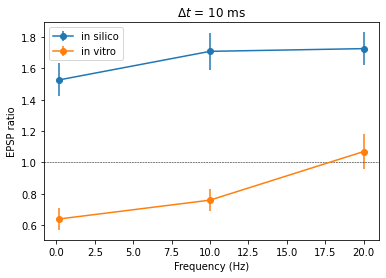

In [6]:
# Plot LTP freq
sel_invitro = invitro[(invitro.reference=='Zilberter et al. 2009') & (invitro.dt_train==10)]
sel_insilico = insilico[(insilico.dt_train==10)]

fig, ax = plot_ratio(sel_insilico, 'in silico', sel_invitro, 'in vitro', offset=False)

ax.set_title(r'$\Delta t$ = 10 ms')

#fig.savefig('l23_l23_zil_ltp.svg')

t-test results for frequency_train = 0.200000: s = 5.519, p = 0.000
t-test results for frequency_train = 20.000000: s = 6.047, p = 0.000


Text(0.5, 1.0, '$\\Delta t$ = -10 ms')

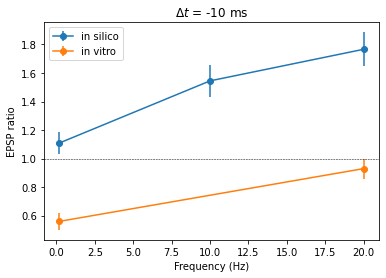

In [7]:
# Plot LTP freq
sel_invitro = invitro[(invitro.reference=='Zilberter et al. 2009') & (invitro.dt_train==-10)]
sel_insilico = insilico[(insilico.dt_train==-10)]

fig, ax = plot_ratio(sel_insilico, 'in silico', sel_invitro, 'in vitro', offset=False)

ax.set_title(r'$\Delta t$ = -10 ms')

#fig.savefig('l23_l23_zil_ltd.svg')

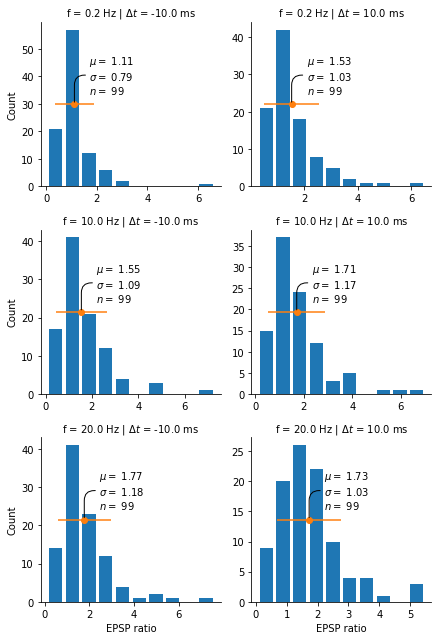

In [8]:
height = 1.5 if pubstyle else 3


def histerrplot(*args, **kwargs):
    data = kwargs.pop('data')
    xvar = kwargs.pop('x')
    values = data[xvar].values
    n = len(values)
    # Get axes
    ax = plt.gca()
    # Plot histograms
    ax.hist(values, rwidth=0.8)
    # Plot errorbar
    ymin, ymax = ax.get_ylim()
    y = (ymin + ymax)/2
    x = np.mean(values)
    xerr = np.std(values)
    ax.errorbar(x, y, xerr=xerr, fmt="-o")
    # Annotate mean and SEM
    arrowprops = dict(arrowstyle="-", connectionstyle="angle,angleA=0,angleB=90,rad=10")
    offset = 10
    ax.annotate("$\mu =$ %.2f\n$\sigma =$ %.2f\n$n =$ %d" % (x, xerr, n), (x, y),
                xytext=(1.5*offset, offset), textcoords='offset points',
                arrowprops=arrowprops)


# Rename columns for clarity
insilico_plot = insilico_exp.rename(columns={"frequency_train": "f",
                                             "dt_train": "$\Delta t$",
                                             "epsp_ratio": "EPSP ratio"})

# Plot grid
g = sns.FacetGrid(insilico_plot, sharex=False, sharey=False,
                  height=height, row="f", col="$\Delta t$")
g.map_dataframe(histerrplot, x="EPSP ratio")
g.set_titles('{row_var} = {row_name} Hz | {col_var} = {col_name} ms')
g.set_ylabels("Count")

#g.savefig("l23_l23_zlb09_hist.png", dpi=300)

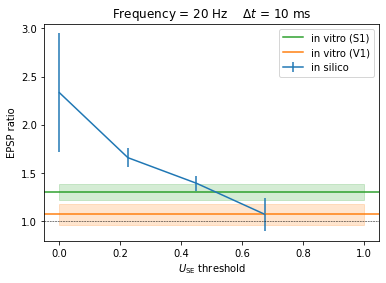

In [9]:
sel_in = insilico_exp[(insilico_exp.dt_train==10) & (insilico_exp.frequency_train==20)]
sel_out = insilico_out[(insilico_out.dt_train==10) & (insilico_out.frequency_train==20)]
sel = pd.concat([sel_in, sel_out])

x = np.linspace(0.0, 0.9, 5)
y = np.array([sel[sel.Use_before_mean > thr]['epsp_ratio'].mean() for thr in x])
yerr = np.array([sel[sel.Use_before_mean > thr]['epsp_ratio'].sem() for thr in x])

#
sel_invitro0 = invitro[(invitro.reference=='Egger et al. 1999') & \
                       (invitro.frequency_train==20) & \
                       (invitro.dt_train==10) & \
                       (invitro.pre_mtype=='L23PC')]
y_invitro0 = sel_invitro0['mean_epsp_ratio'].values
yerr_invitro0 = sel_invitro0['sem_epsp_ratio'].values

#
sel_invitro1 = invitro[(invitro.reference=='Zilberter et al. 2009') & \
                       (invitro.frequency_train==20) & \
                       (invitro.dt_train==10)]
y_invitro1 = sel_invitro1['mean_epsp_ratio'].values
yerr_invitro1 = sel_invitro1['sem_epsp_ratio'].values

fig, ax = plt.subplots()

ax.errorbar(x, y, yerr=yerr, label='in silico')

ax.axhline(y_invitro0, c='C2', label='in vitro (S1)')
ax.fill_between(range(2), y_invitro0 - yerr_invitro0, y_invitro0 + yerr_invitro0,
                color='C2', alpha=0.2)

ax.axhline(y_invitro1, c='C1', label='in vitro (V1)')
ax.fill_between(range(2), y_invitro1 - yerr_invitro1, y_invitro1 + yerr_invitro1,
                color='C1', alpha=0.2)

ax.axhline(1, color='k', lw=.5, ls='dashed')
ax.legend()
ax.set_xlabel('$U_\mathrm{SE}$ threshold')
ax.set_ylabel('EPSP ratio')
ax.set_title(r'Frequency = 20 Hz    $\Delta t$ = 10 ms');

#fig.savefig('l23_l23_zil_use.svg')

Model fit: 1.44 (+/- 0.05) x ^ -0.28 (+/- 0.07)


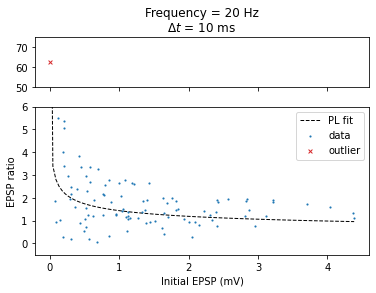

In [10]:
sel_in = insilico_exp[(insilico_exp.dt_train==10) & (insilico_exp.frequency_train==20)]
sel_out = insilico_out[(insilico_out.dt_train==10) & (insilico_out.frequency_train==20)]
sel = pd.concat([sel_in, sel_out])

popt, perr = fit_powerlaw(sel.epsp_before, sel.epsp_ratio)
print('Model fit: %.2f (+/- %.2f) x ^ %.2f (+/- %.2f)' % (popt[0], perr[0], popt[1], perr[1]))
x = np.linspace(0.0001, np.max(sel_in.epsp_before), 100)

fig, (ax_top, ax_bottom) = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [1, 3]})

# Plot data twice
def plot_data(ax):
    ax.scatter(sel_in.epsp_before, sel_in.epsp_ratio, s=5, alpha=1, marker='.', c='C0', label='data')
    ax.scatter(sel_out.epsp_before, sel_out.epsp_ratio, s=15, lw=1, alpha=1, marker='x', c='C3', label='outlier')
    ax.plot(x, powerlaw(x, *popt), lw=1, c='k', ls='dashed', label='PL fit', zorder=-1)
plot_data(ax_top)
plot_data(ax_bottom)

# Set appropriate axis limits
ax_top.set_ylim(50, 75)
ax_bottom.set_ylim(-0.5, 6)
assert sel_in.epsp_ratio.max() < 6
assert sel_in.epsp_ratio.min() > -0.5
assert sel_out.epsp_ratio.max() < 75
assert sel_out.epsp_ratio.min() > -0.5

# Finalize plot
ax_bottom.legend()
ax_top.set_title('Frequency = 20 Hz\n' + r'$\Delta t$ = 10 ms')
ax_bottom.set_ylabel('EPSP ratio')
ax_bottom.set_xlabel('Initial EPSP (mV)')
if pubstyle:
    ax_top.spines['bottom'].set_visible(False)

#fig.savefig('l23_l23_zil_powerlaw.svg')